# GLASS full-sky weak-lensing simulation

The real TR1 catalogue is small (small `f_sky`, few tomographic bins), which limits the QML
pipeline's signal-to-noise and, as found in `examples/example_power_spectra_and_covariance_estimation.ipynb`,
can even push the Fisher-matrix computation into an ill-conditioned regime. This notebook builds
an independent, much larger synthetic weak-lensing shear catalogue using
[GLASS](https://github.com/glass-dev/glass) (Generator for Large Scale Structure), covering the
full sky minus the galactic plane ("Zone of Avoidance") and a band around the ecliptic, to serve
as a larger validation data set for the QML pipeline.

Parameters used here (agreed choices for this first test):
- Footprint: full sky excluding `|b| < 10°` (galactic latitude) and `|beta| < 10°` (ecliptic
  latitude).
- Redshift distribution: the combined/full `n(z)`, i.e. summed over all 6 tomographic bins of
  `TR1/nz.npz`.
- Resolution: `n_side = 64`, a single realisation.

The simulation follows GLASS's own official
[`cosmic_shear.ipynb`](https://github.com/glass-dev/glass/blob/main/examples/2-advanced/cosmic_shear.ipynb)
example workflow (CAMB for the matter power spectrum, lognormal matter fields, multi-plane
convergence, and per-galaxy shear sampling), adapted to this project's fiducial cosmology,
footprint, and redshift distribution. The output is a FITS catalogue (`RA`, `DEC`, `E1`, `E2`,
`W`, `BIN`) in the same column layout that
`examples/example_power_spectra_and_covariance_estimation.ipynb` already expects from a
`heracles.FitsCatalog`, so it can be used as a drop-in replacement for `TR1/catalog.fits` there.

**Package requirements**: in addition to this project's usual environment, this notebook needs
`glass`, `camb`, `cosmology-api`, and `cosmology-compat-camb` (already installed in this
workspace).


In [3]:
import sys

import numpy as np
import healpy as hp
import fitsio
from matplotlib import pyplot as plt

import camb
from cosmology.compat.camb import Cosmology

import glass
import glass.ext.camb

root_filepath = '/home/vscode/WeakLensingQML'
sys.path.append(root_filepath)

plt.rcParams['text.usetex'] = False
rng = np.random.default_rng(seed=42)


## Cosmology

GLASS's matter-power-spectrum machinery (`glass.ext.camb`) is built on
[CAMB](https://camb.info/), not `pyccl` (used elsewhere in this project). We use the same
fiducial cosmology parameters as `examples/example_power_spectra_and_covariance_estimation.ipynb`
(`h`, `Omega_c`, `Omega_b`, `sigma8`, `n_s`), translated into CAMB's parameterisation. CAMB has no
direct `sigma8=` input, so the primordial amplitude `As` is rescaled to match the target
`sigma8`, following the same approach used in `TR1/Heracles_vs_NaMaster_comparison.ipynb`.


In [4]:
# Fiducial cosmology, matching the one used in example_power_spectra_and_covariance_estimation.ipynb
fiducial_cosmology = {'h': 0.7, 'Omega_c': 0.25, 'Omega_b': 0.05, 'sigma8': 0.75, 'n_s': 0.96}

pars = camb.set_params(
    H0=100 * fiducial_cosmology['h'],
    omch2=fiducial_cosmology['Omega_c'] * fiducial_cosmology['h'] ** 2,
    ombh2=fiducial_cosmology['Omega_b'] * fiducial_cosmology['h'] ** 2,
    NonLinear=camb.model.NonLinear_both,
)
pars.InitPower.set_params(As=2e-9, ns=fiducial_cosmology['n_s'])
pars.set_matter_power(redshifts=[0.0], kmax=2.0)

# Rescale As so that CAMB's sigma8 matches our fiducial sigma8 (Cl scales as As, sigma8^2 scales as As too)
sigma8_initial = camb.get_results(pars).get_sigma8()[-1]
As_scaled = 2e-9 * (fiducial_cosmology['sigma8'] / sigma8_initial) ** 2
pars.InitPower.set_params(As=As_scaled, ns=fiducial_cosmology['n_s'])

results = camb.get_background(pars)
cosmo = Cosmology(results)

## Resolution and matter shells

We use `n_side = 64` for this first test (a single realisation). The light cone is split into
radial matter shells out to `z = 3` (the combined `n(z)` from `TR1/nz.npz` is essentially zero
beyond that), and the angular matter power spectrum of each shell is computed with CAMB.


In [5]:
nside = lmax = 64

# shells of 200 Mpc in comoving distance spacing, out to z=3
zb = glass.distance_grid(cosmo, 0.0, 3.0, dx=200.0)
shells = glass.linear_windows(zb)

# angular matter power spectra of the shells, from CAMB
cls = glass.ext.camb.matter_cls(pars, lmax, shells)


## Footprint: galactic + ecliptic cut

`glass.vmap_galactic_ecliptic(nside, galactic=(lo, hi), ecliptic=(lo, hi))` masks a symmetric
strip of colatitude (in **radians**) around each plane's equator (`colatitude = 90°` is the plane
itself), so a `|b| < 20°` cut around the galactic plane corresponds to a colatitude strip of
`(70°, 110°)`, and likewise `(70°, 110°)` for the `|beta| < 20°` ecliptic cut, both converted to
radians with `np.radians(...)` before being passed in. These are wider than the originally agreed
`10°` cuts, to keep the resulting catalogue a manageable size (still far larger f_sky than the
real TR1 mask). We plot the resulting mask below to visually confirm the excluded bands sit where
expected before using it in the simulation - adjust the tuples here if they don't.


In [ ]:
vis = glass.vmap_galactic_ecliptic(nside, galactic=np.radians((55, 125)), ecliptic=np.radians((55, 125)))

f_sky = vis.sum() / vis.size
print(f'f_sky of the GLASS galactic+ecliptic footprint at N_side={nside} is {(f_sky * 100):.3f} %')

hp.mollview(vis, cmap='nipy_spectral', cbar=False,
            title='GLASS footprint (|b|>20 deg, |beta|>20 deg excluded)')
plt.show()


NameError: name 'nside' is not defined

## Matter fields

Set up lognormal matter fields for each shell and a generator that samples correlated matter
overdensity maps shell by shell.


In [6]:
fields = glass.lognormal_fields(shells)

# healpy's pixel window function download is blocked by SSL interception in this environment;
# point it at the local copy in examples/pixel_window_functions/ instead
import healpy.sphtfunc
healpy.sphtfunc.DATAURL = f'file://{root_filepath}/examples/'

# discretisation: HEALPix pixel window (nside), max angular mode number (lmax), correlated shells (ncorr)
cls = glass.discretized_cls(cls, nside=nside, lmax=lmax, ncorr=3)
gls = glass.solve_gaussian_spectra(fields, cls)

matter = glass.generate(fields, gls, nside, ncorr=3, rng=rng)


## Galaxy redshift distribution

Rather than the real bin-4 `n(z)` from `TR1/nz.npz`, we build our own synthetic redshift
distribution here, following the same pattern as GLASS's
[`stage_4_galaxies.ipynb`](https://github.com/glass-dev/glass/blob/main/examples/2-advanced/stage_4_galaxies.ipynb)
example: a Smail-type `n(z)` (`glass.smail_nz`) normalised to a target observed density of
`n_arcmin2 = 30` gals/arcmin². This lands us in the signal-dominated noise regime used for the
$\bar n = 30$ gals/arcmin² case in Maraio et al. (2022), rather than the noise-dominated regime
of the real bin-4 `n(z)` (which only reaches ~1.6 gals/arcmin² over the survey footprint). The
resulting `z`/`dndz` arrays are saved to disk so that the downstream QML pipeline notebook can
use the same fiducial distribution when computing the theory power spectrum.


In [7]:

# Custom Smail n(z), normalised to a target observed density of 30 gals/arcmin^2
n_arcmin2 = 20.0
z_nz = np.arange(0.0, 3.0, 0.01)
dndz = glass.smail_nz(z_nz, z_mode=0.9, alpha=2.0, beta=1.5)
dndz *= n_arcmin2

# distribute the dN/dz over the matter shells
ngal = glass.partition(z_nz, dndz, shells)

# per-component intrinsic ellipticity dispersion (typical literature value)
sigma_e = 0.3

# save the n(z) so the downstream QML pipeline notebook can use the same fiducial distribution
nz_filepath = f'{root_filepath}/data/nz_glass_custom.npz'
np.savez(nz_filepath, z=z_nz, nz=dndz)
print(f'Wrote redshift distribution to {nz_filepath}')



Wrote redshift distribution to /home/vscode/WeakLensingQML/data/nz_glass_custom.npz


## Simulation

For each matter shell, accumulate the convergence via `MultiPlaneConvergence`, derive the shear,
sample galaxy positions from the matter density within the visible footprint, sample intrinsic
ellipticities, and compute the observed (reduced) shear. Positions/ellipticities are streamed
straight to the output FITS catalogue via `glass.write_catalog` to keep memory use low.


In [ ]:
catalog_filepath = f'{root_filepath}/data/glass_catalog_N{nside}.fits'

convergence = glass.MultiPlaneConvergence(cosmo)

with glass.write_catalog(catalog_filepath) as out:
    for i, delta_i in enumerate(matter):
        convergence.add_window(delta_i, shells[i])
        kappa_i = convergence.kappa
        gamm1_i, gamm2_i = glass.shear_from_convergence(kappa_i)

        for gal_lon, gal_lat, gal_count in glass.positions_from_delta(
            ngal[i], delta_i, vis=vis, rng=rng,
        ):
            gal_eps = glass.ellipticity_intnorm(gal_count, sigma_e, rng=rng, xp=np)
            gal_she = glass.galaxy_shear(gal_lon, gal_lat, gal_eps, kappa_i, gamm1_i, gamm2_i)

            out.write(
                RA=gal_lon,
                DEC=gal_lat,
                E1=gal_she.real,
                E2=gal_she.imag,
                W=np.ones_like(gal_lon),
                BIN=np.ones_like(gal_lon, dtype=np.int32),
            )


## Save the footprint mask

Also save the visibility mask as a HEALPix FITS map (same convention as the masks in
`data/masks/`), so it can be used directly in place of the real survey mask.


In [9]:
mask_filepath = f'{root_filepath}/data/masks/SkyMask_glass_N{nside}.fits'
hp.write_map(mask_filepath, vis.astype(float), overwrite=True, fits_IDL=False, dtype=np.float64)

print(f'Wrote catalogue to {catalog_filepath}')
print(f'Wrote mask to {mask_filepath}')


Wrote catalogue to /home/vscode/WeakLensingQML/data/glass_catalog_N64.fits
Wrote mask to /home/vscode/WeakLensingQML/data/masks/SkyMask_glass_N64.fits


## Quick validation

Pixelise the generated catalogue into per-pixel mean-shear maps and plot one as a sanity check.
This is also the only time the (large) catalogue needs to be read: the resulting `gamma1`/`gamma2`
maps are saved to disk here so the QML pipeline notebook can load them directly, instead of
re-reading the full catalogue itself.


Simulated 868069844 galaxies (mean density 20.001 /arcmin^2 within footprint)
Wrote gamma_1 map to /home/vscode/WeakLensingQML/data/Map_glass_N128_gamma1.fits
Wrote gamma_2 map to /home/vscode/WeakLensingQML/data/Map_glass_N128_gamma2.fits


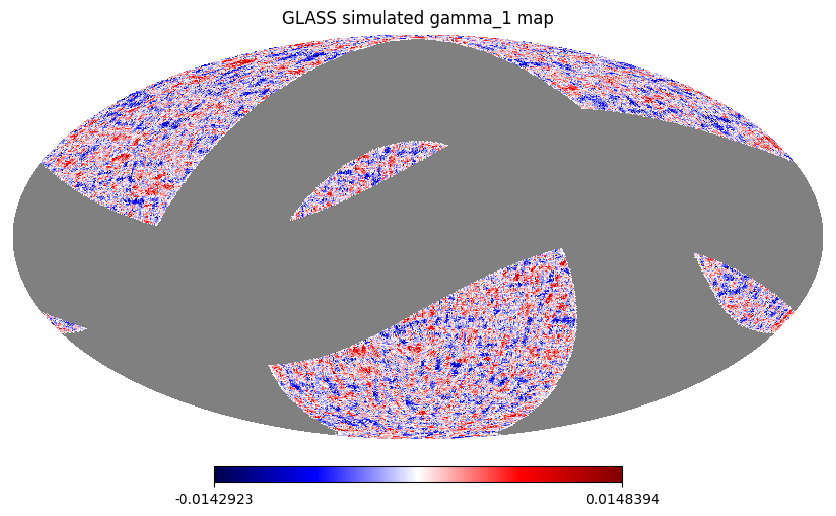

In [9]:
n_pix = 12 * nside * nside
sum_w = np.zeros(n_pix)
sum_w_e1 = np.zeros(n_pix)
sum_w_e2 = np.zeros(n_pix)
n_gal = 0

catalog = fitsio.FITS(catalog_filepath)[1]
for start in range(0, catalog.get_nrows(), 1_000_000):
    page = catalog[start:start + 1_000_000]
    pix = hp.ang2pix(nside, page['RA'], page['DEC'], lonlat=True)
    np.add.at(sum_w, pix, page['W'])
    np.add.at(sum_w_e1, pix, page['W'] * page['E1'])
    np.add.at(sum_w_e2, pix, page['W'] * page['E2'])
    n_gal += len(page)

map_gamma1 = np.divide(sum_w_e1, sum_w, out=np.zeros(n_pix), where=sum_w > 0)
map_gamma2 = np.divide(sum_w_e2, sum_w, out=np.zeros(n_pix), where=sum_w > 0)
map_gamma1 *= vis
map_gamma2 *= vis

footprint_area_arcmin2 = vis.mean() * 4 * np.pi * (180 / np.pi) ** 2 * 3600
print(f'Simulated {n_gal} galaxies (mean density {n_gal / footprint_area_arcmin2:.3f} /arcmin^2 within footprint)')

map_gamma1_path = f'{root_filepath}/data/Map_glass_N{nside}_gamma1.fits'
map_gamma2_path = f'{root_filepath}/data/Map_glass_N{nside}_gamma2.fits'
hp.write_map(map_gamma1_path, map_gamma1, overwrite=True, fits_IDL=False, dtype=np.float64)
hp.write_map(map_gamma2_path, map_gamma2, overwrite=True, fits_IDL=False, dtype=np.float64)
print(f'Wrote gamma_1 map to {map_gamma1_path}')
print(f'Wrote gamma_2 map to {map_gamma2_path}')

plot_map_gamma1 = map_gamma1.copy()
plot_map_gamma1[sum_w == 0] = np.nan
hp.mollview(plot_map_gamma1, cmap='seismic', cbar=True, title='GLASS simulated gamma_1 map')
plt.show()


## Using this catalogue in the QML pipeline notebook

The "Quick validation" step above already pixelises the (large, ~1e9-row) catalogue into
`gamma1`/`gamma2` maps and saves them to `data/Map_glass_N{nside}_gamma1.fits` and
`..._gamma2.fits` - small, fixed-size HEALPix maps, regardless of catalogue size. Point the QML
pipeline notebook at these directly (`hp.read_map`) instead of re-reading `TR1/catalog.fits` or
this notebook's much larger catalogue, to avoid a second heavy catalogue read:
- The mask-building cell (which reads `TR1/vmap.fits.gz`) &rarr; load
  `f'{root_filepath}/data/masks/SkyMask_glass_N{n_side}.fits'` directly with `hp.read_map`
  instead (it is already a binary mask at the target `n_side`, so no downgrading/thresholding is
  needed).
- The catalogue-to-map pixelisation cell (`heracles.FitsCatalog(...)` + the per-pixel
  `sum_weight`/`map_gamma1`/`map_gamma2` accumulation) &rarr; skip entirely; instead load
  `map_gamma1 = hp.read_map(f'{root_filepath}/data/Map_glass_N{n_side}_gamma1.fits')` and likewise
  for `gamma2`.
- The fiducial cosmology cell &rarr; can reuse `fiducial_cosmology` unchanged, since it already
  matches the one used here.

The full catalogue at `f'{root_filepath}/data/glass_catalog_N{n_side}.fits'` is still available if
you need per-galaxy quantities (e.g. to re-pixelise at a different `n_side` or re-bin
tomographically), but is not needed for the power-spectra/QML pipeline itself.

